# TCGA Pan-Cancer Modeling for Predicting TP53 Mutation Status from RNA Expression

This notebook builds a leakage-aware modeling workflow for predicting **TP53 mutation status** from **TCGA RNA expression**.

It is designed to run on **Kaggle**, **Colab**, or local environments, and it can use a **GPU-backed cuML logistic regression** path when RAPIDS is available. If RAPIDS is unavailable, it falls back to a scikit-learn CPU implementation while keeping the same modeling logic.

## Main goals

- build a **tumour-only**, **one-sample-per-patient** TCGA cohort
- define **TP53 nonsynonymous mutation status** from mutation annotations
- compare:
  - dummy baseline
  - cancer-type-only baseline
  - RNA-only elastic-net logistic regression
  - RNA + cancer type combined model
- include a **cancer-type-grouped evaluation** to test for lineage confounding
- optionally inspect RNA coefficients and within-cancer performance

## Runtime note

This notebook prefers the **raw TCGA/Xena files** when they are present:

- `mc3.v0.2.8.PUBLIC.xena`
- `Survival_SupplementalTable_S1_20171025_xena*`
- `tcga_RSEM_gene_tpm`

If those are not present, it falls back to the curated CSV files when possible.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import os
import re
import sys
import subprocess
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)

In [2]:
SEARCH_ROOTS = [Path("/kaggle/input"), Path("/content"), Path("/mnt/data"), Path(".")]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file.\nTried:\n" + "\n".join(tried))
    return None

# Prefer raw TCGA/Xena files when available.
RAW_MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "*mc3.v0.2.8.PUBLIC.xena",
    "*mc3*PUBLIC*xena*",
], required=False)

RAW_PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=False)

RAW_RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "*tcga_RSEM_gene_tpm*",
], required=False)

# Curated CSV fallbacks.
MODEL_PATH = find_first(["Model.csv", "*Model*.csv"], required=False)
OMICS_MUT_PATH = find_first([
    "OmicsSomaticMutations.csv",
    "*OmicsSomaticMutations*.csv",
], required=False)
OMICS_RNA_PATH = find_first([
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    "OmicsExpressionProteinCodingGenesTPML.csv",
    "*OmicsExpressionProteinCodingGenesTPM*.csv",
    "*OmicsExpressionProteinCodingGenesTPML*",
], required=False)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

USE_RAW_TCGA = all(p is not None for p in [RAW_MUT_PATH, RAW_PHENO_PATH, RAW_RNA_PATH])

MUT_PATH = RAW_MUT_PATH if RAW_MUT_PATH is not None else OMICS_MUT_PATH
META_PATH = RAW_PHENO_PATH if RAW_PHENO_PATH is not None else MODEL_PATH
RNA_PATH = RAW_RNA_PATH if RAW_RNA_PATH is not None else OMICS_RNA_PATH

assert MUT_PATH is not None, "Could not locate a mutation file."
assert META_PATH is not None, "Could not locate a metadata / phenotype file."
assert RNA_PATH is not None, "Could not locate an RNA expression file."

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_CV_SPLITS = 5
GROUP_CV_SPLITS = 5
TOP_COEFS_TO_SHOW = 25
TOP_VAR_GENES = 5000
FLOOR_VALUE = -9.9658
MAX_FLOOR_FRAC = 0.95
BOOTSTRAP_RESAMPLES = 1000
MIN_SAMPLES_PER_CLASS = 20

RUN_GROUPED_CV = True
RUN_COMBINED_MODEL = True
RUN_WITHIN_CANCER_EVAL = True

# Runtime controls
GPU_REQUIRED = False
ALLOW_CPU_FALLBACK = True
INSTALL_RAPIDS_IN_COLAB = False
GPU_SEARCH_BACKEND = "cuml"      # {"cuml", "sklearn"}
FINAL_REFIT_BACKEND = "cuml"  # {"sklearn", "cuml"}
WITHIN_CANCER_BACKEND = "cuml"   # {"cuml", "sklearn"}
GROUPED_TUNING_MODE = "reuse_holdout_best"  # {"nested", "reuse_holdout_best"}

META_C_GRID = [0.01, 0.1, 1.0, 10.0]

RNA_PARAM_GRID = {
    "top_k": [2000, 5000],
    "k_select": [250, 500, 1000, 2000],
    "scaler": ["maxabs", "standard"],
    "C": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5, 1.0],
}

COMBO_PARAM_GRID = {
    "top_k": [2000, 5000],
    "k_select": [250, 500, 1000],
    "scaler": ["maxabs", "standard"],
    "C": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5, 1.0],
}

print("Using raw TCGA/Xena inputs:", USE_RAW_TCGA)
print("MUT_PATH =", MUT_PATH)
print("META_PATH =", META_PATH)
print("RNA_PATH =", RNA_PATH)
print("TP53_TARGETS_PATH =", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH =", GENE_ANNOTATION_PATH)
print("RNA grid combinations:", len(list(ParameterGrid(RNA_PARAM_GRID))))
print("Combined grid combinations:", len(list(ParameterGrid(COMBO_PARAM_GRID))))

Using raw TCGA/Xena inputs: True
MUT_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena
META_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp
RNA_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm
TP53_TARGETS_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH = None
RNA grid combinations: 192
Combined grid combinations: 144


## GPU environment setup

The heavy RNA and combined-model searches can use **RAPIDS cuML** if it is available in the runtime.

- If RAPIDS is installed and importable, the manual elastic-net search uses **cuML LogisticRegression**.
- If RAPIDS is unavailable, the notebook falls back to **scikit-learn** automatically unless `GPU_REQUIRED=True`.
- The **final refit** is kept configurable. By default, it uses **scikit-learn** so that the final holdout model remains close to the original CPU notebook.

In [3]:
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle")

if INSTALL_RAPIDS_IN_COLAB and IN_COLAB:
    utils_dir = Path("./rapidsai-csp-utils")
    if not utils_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/rapidsai/rapidsai-csp-utils.git"],
            check=True,
        )
    subprocess.run([sys.executable, "rapidsai-csp-utils/colab/pip-install.py"], check=True)

GPU_AVAILABLE = False
GPU_IMPORT_ERROR = None
cp = None
cuLogisticRegression = None
cuml = None

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression

    GPU_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    GPU_IMPORT_ERROR = repr(e)

if GPU_REQUIRED and not GPU_AVAILABLE and not ALLOW_CPU_FALLBACK:
    raise RuntimeError(
        "GPU_REQUIRED=True but cuML/CuPy could not be imported. "
        "Install RAPIDS in a compatible CUDA environment first."
    )

if GPU_SEARCH_BACKEND == "cuml" and not GPU_AVAILABLE:
    if ALLOW_CPU_FALLBACK:
        print("cuML not available; falling back to scikit-learn CPU search.")
        GPU_SEARCH_BACKEND = "sklearn"
        if FINAL_REFIT_BACKEND == "cuml":
            FINAL_REFIT_BACKEND = "sklearn"
        if WITHIN_CANCER_BACKEND == "cuml":
            WITHIN_CANCER_BACKEND = "sklearn"
    else:
        raise RuntimeError("GPU search requested but cuML/CuPy are unavailable.")

gpu_name = None
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        text=True,
    ).strip().splitlines()
    gpu_name = smi[0] if smi else None
except Exception:
    pass

print("In Colab:", IN_COLAB)
print("In Kaggle:", IN_KAGGLE)
print("GPU available:", GPU_AVAILABLE)
print("GPU import error:", GPU_IMPORT_ERROR)
print("Detected GPU name:", gpu_name)
print("GPU search backend:", GPU_SEARCH_BACKEND)
print("Final refit backend:", FINAL_REFIT_BACKEND)
print("Within-cancer backend:", WITHIN_CANCER_BACKEND)
print("Grouped tuning mode:", GROUPED_TUNING_MODE)

In Colab: False
In Kaggle: True
GPU available: True
GPU import error: None
Detected GPU name: Tesla T4
GPU search backend: cuml
Final refit backend: cuml
Within-cancer backend: cuml
Grouped tuning mode: reuse_holdout_best


## Load mutation and metadata tables

The notebook first loads the mutation and metadata / phenotype tables, infers the relevant schema, and only then loads the RNA matrix after the modeling cohort is frozen.

This avoids loading the full expression matrix too early.

In [4]:
def sniff_sep(path):
    with open(path, "r", errors="ignore") as f:
        line = f.readline()
    if line.count("\t") > line.count(","):
        return "\t"
    return ","

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None

def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))

def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))

def normalize_sample_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s

def normalize_patient_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s

def tcga_sample_type_code(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan

TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan

def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

MUT_SEP = sniff_sep(MUT_PATH)
META_SEP = sniff_sep(META_PATH)
RNA_SEP = sniff_sep(RNA_PATH)

mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
meta_raw = pd.read_csv(META_PATH, sep=META_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=3, low_memory=False)

print("mut_raw shape:", mut_raw.shape)
print("meta_raw shape:", meta_raw.shape)
print("rna_header preview shape:", rna_header.shape)
print("mut_raw columns:", mut_raw.columns.tolist()[:20])
print("meta_raw columns:", meta_raw.columns.tolist()[:20])
print("RNA first columns:", list(rna_header.columns[:8]))

MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

META_SAMPLE_COL = find_col(
    meta_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "metadata sample column",
)
PATIENT_COL = find_col(
    meta_raw,
    ["patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    meta_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen metadata sample column:", META_SAMPLE_COL)
print("Chosen patient column:", PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

mut_raw shape: (2907335, 12)
meta_raw shape: (12591, 34)
rna_header preview shape: (3, 10536)
mut_raw columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
meta_raw columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']
Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect']
Chosen metadata sample column: sample
Chosen patient column: _P

## Infer RNA matrix orientation and available samples

The notebook supports two RNA layouts:

1. **sample × gene**  
   first column is sample ID, remaining columns are genes

2. **gene × sample**  
   first column is gene ID, remaining columns are sample IDs

The loader detects the layout automatically and then loads only the retained cohort later.

In [5]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}

    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    # Strong clues from header names.
    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    # Fallback using first few row values.
    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    # Conservative default for TCGA-like Xena matrices.
    return "sample_x_gene"

RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

def get_rna_available_samples(path, sep, orientation):
    if orientation == "gene_x_sample":
        header = pd.read_csv(path, sep=sep, nrows=0)
        sample_ids = [normalize_sample_id(c) for c in header.columns[1:]]
        return pd.Index(pd.unique(pd.Series(sample_ids).dropna()), name="sample_id")

    sample_ids = []
    for chunk in pd.read_csv(path, sep=sep, usecols=[0], chunksize=5000, low_memory=False):
        vals = chunk.iloc[:, 0].map(normalize_sample_id)
        sample_ids.extend(vals.dropna().tolist())
    return pd.Index(pd.unique(pd.Series(sample_ids)), name="sample_id")

rna_available_samples = get_rna_available_samples(RNA_PATH, RNA_SEP, RNA_ORIENTATION)

print("RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)
print("Number of RNA-available samples:", len(rna_available_samples))
print("Example RNA-available samples:", rna_available_samples[:5].tolist())

RNA orientation: gene_x_sample
RNA first column: sample
Number of RNA-available samples: 10535
Example RNA-available samples: ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']


## Rebuild the TP53 sample-level label

This follows the same scientific rule as before:

- `TP53_mut_nonsyn = 1` if a sample has at least one protein-altering TP53 event
- ambiguous / mixed cases are tracked and later excluded from modeling

In [6]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("rate"))

TP53 mutation rows: 3729


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


,rate
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


## Build phenotype metadata and freeze the modeling cohort

This section applies the leakage-aware cohort rules before any large RNA matrix is loaded:

- retain only samples with RNA available
- keep tumour samples only
- require non-missing cancer type
- remove ambiguous or mixed TP53 labels
- keep exactly one sample per patient

In [7]:
meta = meta_raw.copy()
meta["sample_id"] = meta[META_SAMPLE_COL].map(normalize_sample_id)

if PATIENT_COL is not None:
    meta["patient_id"] = meta[PATIENT_COL]
else:
    meta["patient_id"] = meta["sample_id"].map(normalize_patient_id)

meta["patient_id"] = meta["patient_id"].fillna(meta["sample_id"].map(normalize_patient_id))
meta["sample_type_code"] = meta["sample_id"].map(tcga_sample_type_code)
meta["sample_type_label"] = meta["sample_id"].map(tcga_sample_type_label)

if USE_RAW_TCGA:
    meta["is_tumor_sample"] = meta["sample_id"].map(is_tcga_tumor_sample)
else:
    # For non-TCGA fallback tables, keep all rows by default.
    meta["is_tumor_sample"] = True

meta["in_rna"] = meta["sample_id"].isin(rna_available_samples)

meta = meta.merge(tp53_sample, on="sample_id", how="left", suffixes=("", "_tp53"))
if "patient_id_tp53" in meta.columns:
    meta["patient_id"] = meta["patient_id"].fillna(meta["patient_id_tp53"])

meta["TP53_mut_nonsyn"] = meta["TP53_mut_nonsyn"].fillna(0).astype(int)
meta["TP53_mut_ambiguous"] = meta["TP53_mut_ambiguous"].fillna(0).astype(int)
meta["has_any_tp53_row"] = meta["has_any_tp53_row"].fillna(False).astype(bool)
meta["has_mixed_tp53_annotation"] = meta["has_mixed_tp53_annotation"].fillna(0).astype(int)

SAMPLE_PRIORITY = {
    "01": 0,
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}

model_meta = meta.copy()
model_meta = model_meta.loc[model_meta["in_rna"]].copy()
model_meta = model_meta.loc[model_meta["is_tumor_sample"].fillna(False)].copy()
model_meta = model_meta.loc[model_meta[CANCER_TYPE_COL].notna()].copy()
model_meta = model_meta.loc[
    (model_meta["TP53_mut_ambiguous"] == 0) &
    (model_meta["has_mixed_tp53_annotation"] == 0)
].copy()

pre_dedup_n = len(model_meta)
pre_dedup_multi_patient_counts = (
    model_meta["patient_id"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)
)

model_meta["sample_priority"] = model_meta["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_meta = (
    model_meta.sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cohort_summary = pd.Series({
    "n_rows": len(model_meta),
    "n_unique_samples": model_meta["sample_id"].nunique(),
    "n_unique_patients": model_meta["patient_id"].nunique(),
    "tp53_prevalence": model_meta["TP53_mut_nonsyn"].mean(),
    "n_cancer_types": model_meta[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_meta["patient_id"].isna().sum() == 0, "Patient IDs must be present after backfill."
assert model_meta["patient_id"].nunique() == len(model_meta), "Exactly one sample per patient should remain."
assert set(model_meta["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."
print("Final cohort passes basic leakage-sensitive checks.")

,value
n_rows,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-G5-6572,2
TCGA-2G-AAKG,2
TCGA-ER-A2NF,2
TCGA-K1-A42X,2
TCGA-TM-A7CF,2
TCGA-QR-A6GZ,2
TCGA-K1-A3PN,2
TCGA-HM-A6W2,2


Final cohort passes basic leakage-sensitive checks.


## Load RNA for the final retained cohort only

The loader handles either:

- **sample × gene** RNA matrices by chunking through rows and keeping only retained samples
- **gene × sample** RNA matrices by loading only the retained sample columns and then transposing

In [8]:
def load_rna_subset(path, sep, orientation, selected_sample_ids):
    selected_sample_ids = list(pd.Index(selected_sample_ids).astype(str))
    selected_set = set(selected_sample_ids)

    if orientation == "sample_x_gene":
        chunks = []
        for chunk in pd.read_csv(path, sep=sep, chunksize=256, low_memory=False):
            first_col = chunk.columns[0]
            chunk["sample_id"] = chunk[first_col].map(normalize_sample_id)
            sub = chunk.loc[chunk["sample_id"].isin(selected_set)].copy()
            if len(sub) == 0:
                continue
            keep_cols = ["sample_id"] + [c for c in sub.columns if c not in {first_col, "sample_id"}]
            sub = sub[keep_cols]
            chunks.append(sub)

        if len(chunks) == 0:
            raise ValueError("No selected samples were found in the RNA matrix.")

        rna_df = pd.concat(chunks, axis=0, ignore_index=True)
        rna_df = rna_df.drop_duplicates("sample_id", keep="first")
        rna_df = rna_df.set_index("sample_id")
        rna_df = rna_df.reindex(selected_sample_ids)
        rna_df.index.name = "sample_id"
        rna_df.columns.name = None
        rna_df = rna_df.apply(pd.to_numeric, errors="coerce").astype(np.float32)
        return rna_df

    # gene × sample
    header = pd.read_csv(path, sep=sep, nrows=0)
    first_col = header.columns[0]
    sample_cols = [c for c in header.columns[1:] if normalize_sample_id(c) in selected_set]
    if len(sample_cols) == 0:
        raise ValueError("No selected samples matched RNA columns in a gene × sample matrix.")

    subset = pd.read_csv(path, sep=sep, usecols=[first_col] + sample_cols, low_memory=False)
    subset = subset.rename(columns={first_col: "feature_id"})

    rename_map = {c: normalize_sample_id(c) for c in sample_cols}
    subset = subset.rename(columns=rename_map)

    # If multiple original columns collapse to the same normalized sample_id, average them.
    dup_cols = pd.Index(subset.columns[1:]).duplicated(keep=False)
    if dup_cols.any():
        feature = subset["feature_id"]
        values = subset.drop(columns=["feature_id"])
        values = values.groupby(level=0, axis=1).mean()
        subset = pd.concat([feature, values], axis=1)

    subset = subset.set_index("feature_id")
    subset = subset.apply(pd.to_numeric, errors="coerce")
    rna_df = subset.T
    rna_df.index = pd.Index(rna_df.index.map(normalize_sample_id), name="sample_id")
    rna_df = rna_df.groupby(level=0).mean()
    rna_df = rna_df.reindex(selected_sample_ids)
    rna_df.columns.name = None
    rna_df = rna_df.astype(np.float32)
    return rna_df

selected_sample_ids = model_meta["sample_id"].tolist()
rna_mat = load_rna_subset(RNA_PATH, RNA_SEP, RNA_ORIENTATION, selected_sample_ids)

assert rna_mat.shape[0] == len(selected_sample_ids), "RNA sample count does not match retained cohort."
assert rna_mat.index.equals(pd.Index(selected_sample_ids, name="sample_id")), "RNA sample order mismatch."

print("rna_mat shape (samples x genes):", rna_mat.shape)
print("RNA missing fraction:", float(rna_mat.isna().mean().mean()))
print("RNA dtype summary:")
print(rna_mat.dtypes.value_counts().head())
print(
    "Observed RNA min / median / max:",
    float(np.nanmin(rna_mat.to_numpy())),
    float(np.nanmedian(rna_mat.to_numpy())),
    float(np.nanmax(rna_mat.to_numpy())),
)
print("Overall fraction exactly at floor value:", float(np.isclose(rna_mat.to_numpy(), FLOOR_VALUE, atol=1e-6).mean()))
display(rna_mat.iloc[:3, :5])

rna_mat shape (samples x genes): (9695, 60498)
RNA missing fraction: 0.0
RNA dtype summary:
float32    60498
Name: count, dtype: int64
Observed RNA min / median / max: -9.965800285339355 -9.965800285339355 19.211000442504883
Overall fraction exactly at floor value: 0.5393398792088584


,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-02-0047-01,0.0158,-9.9658,-0.8863,5.9750,-9.9658
TCGA-02-0055-01,-9.9658,-9.9658,-3.8160,5.2506,-9.9658
TCGA-02-2483-01,-9.9658,-9.9658,-5.5735,5.4519,-9.9658


## Prepare train/test data

In [9]:
y = model_meta["TP53_mut_nonsyn"].astype(np.int8).to_numpy()
groups = model_meta[CANCER_TYPE_COL].astype(str).to_numpy()
X_meta = model_meta[[CANCER_TYPE_COL]].copy()
X_rna = rna_mat.to_numpy(dtype=np.float32, copy=True)
gene_ids = np.array(rna_mat.columns)

del rna_mat
_ = gc.collect()

print("X_meta shape:", X_meta.shape)
print("X_rna shape:", X_rna.shape)
print("X_rna dtype:", X_rna.dtype)
print("Positive class rate:", y.mean())

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(np.zeros(len(y)), y))

X_meta_train, X_meta_test = X_meta.iloc[train_idx], X_meta.iloc[test_idx]
X_rna_train, X_rna_test = X_rna[train_idx], X_rna[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
patient_train = model_meta.iloc[train_idx]["patient_id"]
patient_test = model_meta.iloc[test_idx]["patient_id"]

assert set(patient_train).isdisjoint(set(patient_test)), "Patient overlap detected across train/test."

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())

X_meta shape: (9695, 1)
X_rna shape: (9695, 60498)
X_rna dtype: float32
Positive class rate: 0.3116039195461578
Train size: 7756
Test size: 1939
Train prevalence: 0.31162970603403817
Test prevalence: 0.3115007735946364


## Evaluation helpers

In [10]:
def subset_X(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]

def evaluate_from_proba(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, y_proba),
        "auprc": average_precision_score(y_true, y_proba),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_proba),
    }

def plot_roc_pr_curves(y_true, y_proba, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"{title_prefix} ROC")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")

    axes[1].plot(recall, precision)
    axes[1].set_title(f"{title_prefix} Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()

def evaluate_fitted_model(name, fitted_estimator, X_test, y_test, threshold=0.5, show_plots=True):
    y_proba = fitted_estimator.predict_proba(X_test)[:, 1]
    metrics = pd.Series({"model": name, **evaluate_from_proba(y_test, y_proba, threshold=threshold)})

    print()
    print(name)
    display(metrics.to_frame("value"))

    y_pred = (y_proba >= threshold).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=3))

    if show_plots:
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.show()
        plot_roc_pr_curves(y_test, y_proba, title_prefix=name)

    return metrics, y_proba

def bootstrap_metric_ci(y_true, y_proba, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_proba[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

## Baseline 1: Dummy classifier

In [11]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_proba = dummy.predict_proba(np.zeros((len(y_test), 1)))[:, 1]
dummy_metrics = pd.Series({"model": "dummy_prior", **evaluate_from_proba(y_test, dummy_proba)})
display(dummy_metrics.to_frame("value"))

,value
model,dummy_prior
auroc,0.5
auprc,0.311501
balanced_accuracy,0.5
f1,0.0
brier,0.214468


## Baseline 2: Cancer-type-only logistic regression

Best metadata params: {'clf__C': 10.0}
Best metadata CV AUPRC: 0.6666887208864052

metadata_only_cancer_type


,value
model,metadata_only_cancer_type
auroc,0.82418
auprc,0.647466
balanced_accuracy,0.749707
f1,0.649492
brier,0.179839


Confusion matrix:


,pred_0,pred_1
true_0,943,392
true_1,125,479


Classification report:
              precision    recall  f1-score   support

           0      0.883     0.706     0.785      1335
           1      0.550     0.793     0.649       604

    accuracy                          0.733      1939
   macro avg      0.716     0.750     0.717      1939
weighted avg      0.779     0.733     0.743      1939



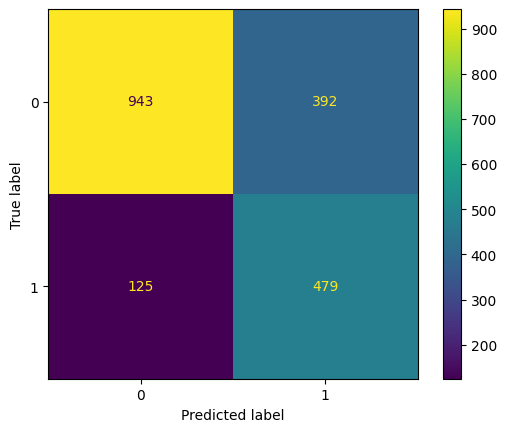

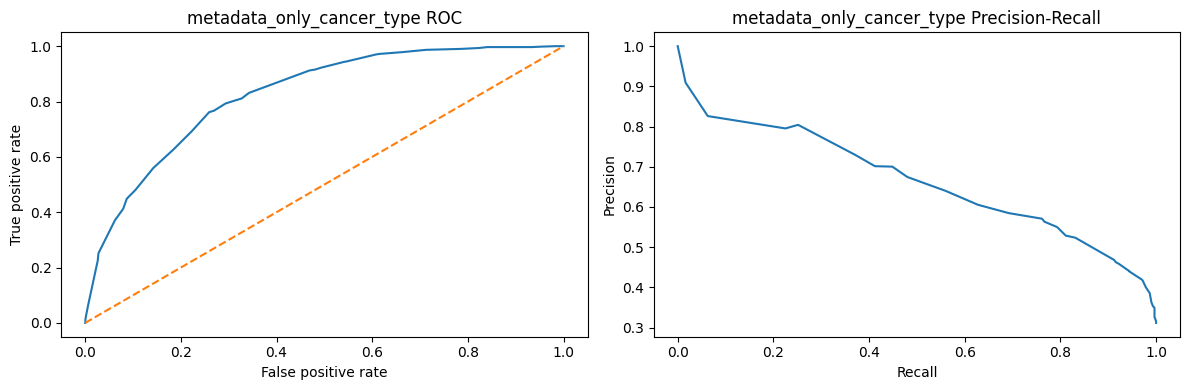

In [12]:
inner_cv = StratifiedKFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

meta_pipe = Pipeline([
    (
        "prep",
        ColumnTransformer(
            transformers=[
                ("cancer_type", OneHotEncoder(handle_unknown="ignore"), [CANCER_TYPE_COL]),
            ],
            remainder="drop",
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
])

meta_grid = GridSearchCV(
    estimator=meta_pipe,
    param_grid={"clf__C": META_C_GRID},
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=1,
    pre_dispatch=1,
    refit=True,
)

meta_grid.fit(X_meta_train, y_train)
print("Best metadata params:", meta_grid.best_params_)
print("Best metadata CV AUPRC:", meta_grid.best_score_)

meta_metrics, meta_test_proba = evaluate_fitted_model(
    name="metadata_only_cancer_type",
    fitted_estimator=meta_grid.best_estimator_,
    X_test=X_meta_test,
    y_test=y_test,
)

## Main model: RNA-only elastic-net logistic regression

This uses the same scientific model family as the CPU notebook, but the search loop is implemented manually so that the heavy elastic-net fits can use **cuML** when available.

Per training fold, the RNA pipeline does:

- floor-value filtering
- top-variance prefiltering
- `SelectKBest`
- scaling
- elastic-net logistic regression

In [13]:
def compute_floor_fraction(X, floor_value=FLOOR_VALUE):
    X = np.asarray(X, dtype=np.float32)
    return (X == np.float32(floor_value)).mean(axis=0)

def fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC):
    floor_frac = compute_floor_fraction(X_train, floor_value=floor_value)
    keep_idx = np.where(floor_frac <= max_floor_frac)[0]
    if len(keep_idx) == 0:
        raise ValueError("All features were removed by the floor filter.")
    return {
        "floor_value": float(floor_value),
        "max_floor_frac": float(max_floor_frac),
        "floor_frac": floor_frac,
        "keep_idx": keep_idx,
    }

def transform_floor_filter(floor_filter, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, floor_filter["keep_idx"]], dtype=np.float32)

def fit_topvar_indices(X_train, top_k):
    X_train = np.asarray(X_train, dtype=np.float32)
    k = min(int(top_k), X_train.shape[1])
    variances = np.nanvar(X_train, axis=0)
    support_idx = np.argpartition(variances, -k)[-k:]
    support_idx = support_idx[np.argsort(variances[support_idx])[::-1]]
    return {
        "top_k": int(top_k),
        "support_idx": support_idx,
        "variances": variances,
    }

def transform_topvar(topvar_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, topvar_obj["support_idx"]], dtype=np.float32)

def fit_kbest_indices(X_train, y_train, k_select):
    X_train = np.asarray(X_train, dtype=np.float32)
    k_eff = min(int(k_select), X_train.shape[1])
    scores, pvals = f_classif(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, neginf=-np.inf, posinf=np.inf)
    support_idx = np.argpartition(scores, -k_eff)[-k_eff:]
    support_idx = support_idx[np.argsort(scores[support_idx])[::-1]]
    return {
        "k_select": int(k_select),
        "k_effective": int(k_eff),
        "support_idx": support_idx,
        "scores": scores,
        "pvals": pvals,
    }

def transform_kbest(kbest_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, kbest_obj["support_idx"]], dtype=np.float32)

def fit_scaler(X_train, scaler_name):
    if scaler_name == "maxabs":
        scaler = MaxAbsScaler()
    elif scaler_name == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unknown scaler_name: {scaler_name}")
    scaler.fit(X_train)
    return scaler

def transform_scaler(scaler, X):
    X_out = scaler.transform(X)
    return np.ascontiguousarray(np.asarray(X_out, dtype=np.float32), dtype=np.float32)

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float32)

def fit_meta_encoder(meta_df):
    enc = make_onehot_encoder()
    enc.fit(meta_df[[CANCER_TYPE_COL]])
    return enc

def transform_meta_encoder(enc, meta_df):
    X_meta_ready = enc.transform(meta_df[[CANCER_TYPE_COL]])
    return np.ascontiguousarray(np.asarray(X_meta_ready, dtype=np.float32), dtype=np.float32)

def fit_rna_preprocessor(X_train, y_train, params):
    floor_filter = fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC)
    X_floor = transform_floor_filter(floor_filter, X_train)

    topvar_obj = fit_topvar_indices(X_floor, top_k=params["top_k"])
    X_topvar = transform_topvar(topvar_obj, X_floor)

    kbest_obj = fit_kbest_indices(X_topvar, y_train, k_select=params["k_select"])
    X_selected = transform_kbest(kbest_obj, X_topvar)

    scaler = fit_scaler(X_selected, scaler_name=params["scaler"])
    return {
        "params": dict(params),
        "floor_filter": floor_filter,
        "topvar_obj": topvar_obj,
        "kbest_obj": kbest_obj,
        "scaler": scaler,
    }

def transform_rna_preprocessor(preproc, X):
    X_floor = transform_floor_filter(preproc["floor_filter"], X)
    X_topvar = transform_topvar(preproc["topvar_obj"], X_floor)
    X_selected = transform_kbest(preproc["kbest_obj"], X_topvar)
    return transform_scaler(preproc["scaler"], X_selected)

def fit_binary_logreg_ready(X_train_ready, y_train, C, l1_ratio, backend="sklearn"):
    backend = backend.lower()
    y_train = np.asarray(y_train).astype(np.int32)

    if backend == "sklearn":
        X_fit = np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float64))
        clf = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            C=float(C),
            l1_ratio=float(l1_ratio),
        )
        clf.fit(X_fit, y_train)
        return clf

    if backend == "cuml":
        if not GPU_AVAILABLE:
            raise RuntimeError("backend='cuml' requested but GPU stack is unavailable.")
        X_fit = cp.asarray(np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float32)))
        y_fit = cp.asarray(y_train)
        clf = cuLogisticRegression(
            penalty="elasticnet",
            C=float(C),
            l1_ratio=float(l1_ratio),
            max_iter=3000,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_fit, y_fit)
        return clf

    raise ValueError(f"Unknown backend: {backend}")

def predict_binary_proba_ready(clf, X_ready):
    X_ready = np.asarray(X_ready)
    if GPU_AVAILABLE and cuLogisticRegression is not None and isinstance(clf, cuLogisticRegression):
        X_pred = cp.asarray(np.ascontiguousarray(X_ready.astype(np.float32)))
    else:
        X_pred = np.ascontiguousarray(X_ready.astype(np.float64))
    proba = clf.predict_proba(X_pred)[:, 1]
    return np.asarray(proba, dtype=np.float64)

def fit_rna_artifact(X_train, y_train, params, backend="sklearn"):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_binary_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "rna",
        "backend": backend,
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }

def predict_rna_artifact(artifact, X):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    return predict_binary_proba_ready(artifact["model"], X_ready)

def fit_combo_artifact(X_meta_train, X_rna_train, y_train, params, backend="sklearn"):
    encoder = fit_meta_encoder(X_meta_train)
    X_meta_ready = transform_meta_encoder(encoder, X_meta_train)

    rna_preproc = fit_rna_preprocessor(X_rna_train, y_train, params=params)
    X_rna_ready = transform_rna_preprocessor(rna_preproc, X_rna_train)

    X_combo_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    clf = fit_binary_logreg_ready(
        X_combo_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "combo",
        "backend": backend,
        "params": dict(params),
        "encoder": encoder,
        "rna_preproc": rna_preproc,
        "model": clf,
    }

def predict_combo_artifact(artifact, X_meta, X_rna):
    X_meta_ready = transform_meta_encoder(artifact["encoder"], X_meta)
    X_rna_ready = transform_rna_preprocessor(artifact["rna_preproc"], X_rna)
    X_combo_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    return predict_binary_proba_ready(artifact["model"], X_combo_ready)

def materialize_cv_splits(splitter, y, groups=None):
    dummy_X = np.zeros((len(y), 1), dtype=np.float32)
    if groups is None:
        return list(splitter.split(dummy_X, y))
    return list(splitter.split(dummy_X, y, groups))

def manual_cv_search_rna(
    X,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="RNA",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_rna_artifact(
                X_train=X[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_rna_artifact(artifact, X[val_idx])
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_rna_artifact(X, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }

def manual_cv_search_combo(
    X_meta,
    X_rna,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="COMBO",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_combo_artifact(
                X_meta_train=subset_X(X_meta, tr_idx),
                X_rna_train=X_rna[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_combo_artifact(
                artifact,
                X_meta=subset_X(X_meta, val_idx),
                X_rna=X_rna[val_idx],
            )
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_combo_artifact(X_meta, X_rna, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }

def crossval_fixed_rna_params(X, y, splitter, params, backend="cuml"):
    splits = materialize_cv_splits(splitter, y)
    rows = []
    for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
        artifact = fit_rna_artifact(X[tr_idx], y[tr_idx], params=params, backend=backend)
        val_proba = predict_rna_artifact(artifact, X[val_idx])
        rows.append({"fold": fold_idx, **evaluate_from_proba(y[val_idx], val_proba)})
    return pd.DataFrame(rows)

def extract_rna_feature_names(preproc, gene_ids):
    genes_after_floor = gene_ids[preproc["floor_filter"]["keep_idx"]]
    genes_after_topvar = genes_after_floor[preproc["topvar_obj"]["support_idx"]]
    final_genes = genes_after_topvar[preproc["kbest_obj"]["support_idx"]]
    return np.asarray(final_genes)

train_floor_frac = compute_floor_fraction(X_rna_train, floor_value=FLOOR_VALUE)
floor_diag = pd.DataFrame({
    "ensembl_gene_id": gene_ids,
    "train_floor_frac": train_floor_frac,
})
print("Genes with >95% floor in training set:", int((floor_diag["train_floor_frac"] > MAX_FLOOR_FRAC).sum()))
display(floor_diag.sort_values("train_floor_frac", ascending=False).head(20))

rna_search = manual_cv_search_rna(
    X=X_rna_train,
    y=y_train,
    splitter=inner_cv,
    param_grid=RNA_PARAM_GRID,
    search_backend=GPU_SEARCH_BACKEND,
    refit_backend=FINAL_REFIT_BACKEND,
    groups=None,
    verbose=1,
    label="RNA",
)

print("Best RNA params:", rna_search["best_params"])
print("Best RNA CV AUPRC:", rna_search["best_score"])
display(rna_search["cv_results"].head(10))

combo_search = None
best_combo_artifact = None

Genes with >95% floor in training set: 18708


,ensembl_gene_id,train_floor_frac
12701,ENSG00000252268.1,1.0
12682,ENSG00000266624.1,1.0
12672,ENSG00000281253.1,1.0
12557,ENSG00000221021.1,1.0
12559,ENSG00000201805.1,1.0
12548,ENSG00000252363.1,1.0
12712,ENSG00000274095.1,1.0
12713,ENSG00000266645.1,1.0
12574,ENSG00000252439.1,1.0
12569,ENSG00000238540.1,1.0


RNA search: 1/192 combos done | current best mean CV AUPRC = 0.6763
[2026-04-29 13:43:47.738] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:45:12.877] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:45:43.754] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:45:58.210] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:46:05.435] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:46:52.368] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:47:29.450] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 13:47:37.493] [CUML] [warning] QWL-QN stopped

,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.100,2000,1.0,maxabs,5000,0.812045,0.015919
1,0.100,1000,0.5,maxabs,5000,0.809565,0.020379
2,0.100,1000,1.0,maxabs,5000,0.808659,0.019233
3,0.010,2000,0.5,standard,5000,0.808308,0.015374
4,0.010,2000,0.0,maxabs,5000,0.807662,0.014779
5,0.100,1000,1.0,standard,5000,0.807466,0.020548
6,0.001,2000,0.0,standard,5000,0.807249,0.012315
7,0.010,1000,0.0,maxabs,5000,0.806573,0.017716
8,0.100,2000,0.5,maxabs,5000,0.806257,0.016414
9,0.010,1000,0.0,standard,5000,0.803199,0.020848



rna_only_elastic_net_logreg


,value
model,rna_only_elastic_net_logreg
auroc,0.905968
auprc,0.78065
balanced_accuracy,0.844066
f1,0.770504
brier,0.117723


Confusion matrix:


,pred_0,pred_1
true_0,1122,213
true_1,92,512


Classification report:
              precision    recall  f1-score   support

           0      0.924     0.840     0.880      1335
           1      0.706     0.848     0.771       604

    accuracy                          0.843      1939
   macro avg      0.815     0.844     0.825      1939
weighted avg      0.856     0.843     0.846      1939



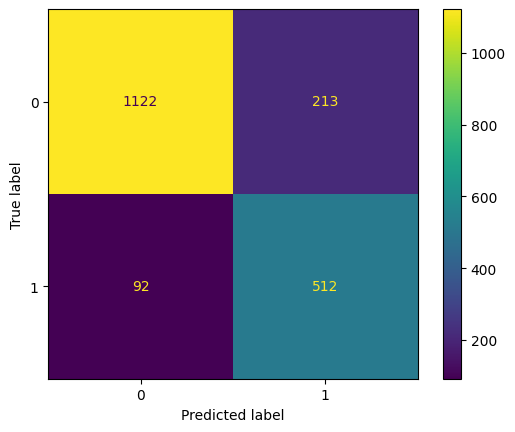

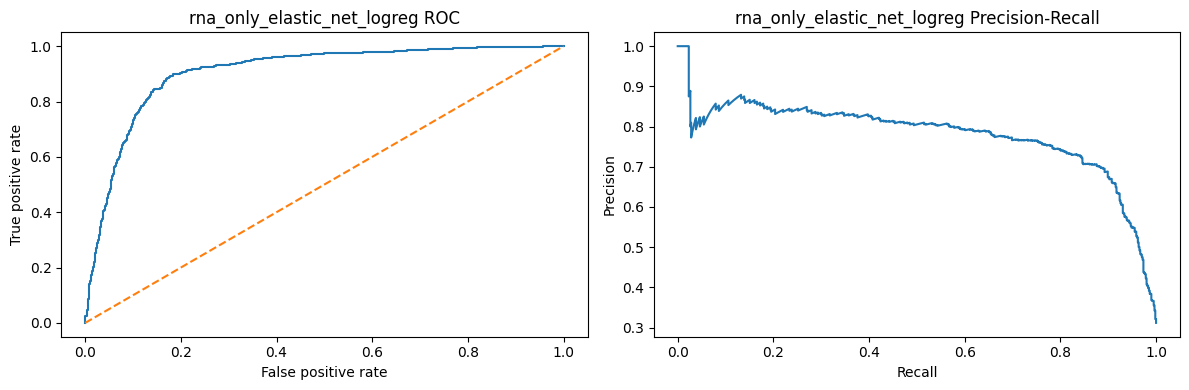

In [14]:
best_rna_artifact = rna_search["best_artifact"]
rna_test_proba = predict_rna_artifact(best_rna_artifact, X_rna_test)
rna_metrics = pd.Series({"model": "rna_only_elastic_net_logreg", **evaluate_from_proba(y_test, rna_test_proba)})

print()
print("rna_only_elastic_net_logreg")
display(rna_metrics.to_frame("value"))

rna_test_pred = (rna_test_proba >= 0.5).astype(int)
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, rna_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
print("Classification report:")
print(classification_report(y_test, rna_test_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, rna_test_pred)
plt.show()
plot_roc_pr_curves(y_test, rna_test_proba, title_prefix="rna_only_elastic_net_logreg")

## Holdout comparison and calibration diagnostics

,model,auroc,auprc,balanced_accuracy,f1,brier
0,rna_only_elastic_net_logreg,0.905968,0.780650,0.844066,0.770504,0.117723
1,metadata_only_cancer_type,0.824180,0.647466,0.749707,0.649492,0.179839
2,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


,model,auroc_ci_2.5,auroc_ci_50,auroc_ci_97.5,auprc_ci_2.5,auprc_ci_50,auprc_ci_97.5
0,metadata_only_cancer_type,0.805283,0.824262,0.843425,0.607292,0.648540,0.687486
1,rna_only_elastic_net_logreg,0.891810,0.906019,0.919345,0.743482,0.781407,0.816106


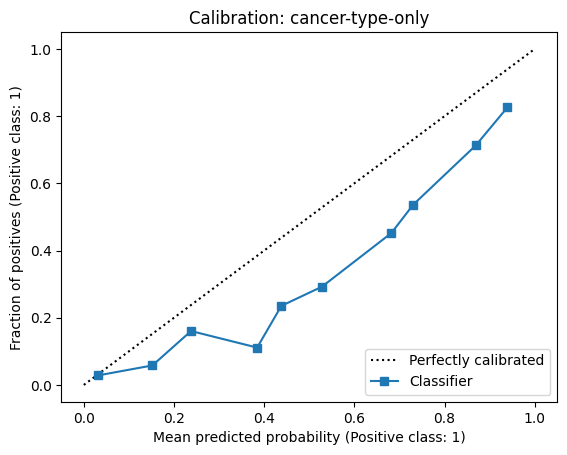

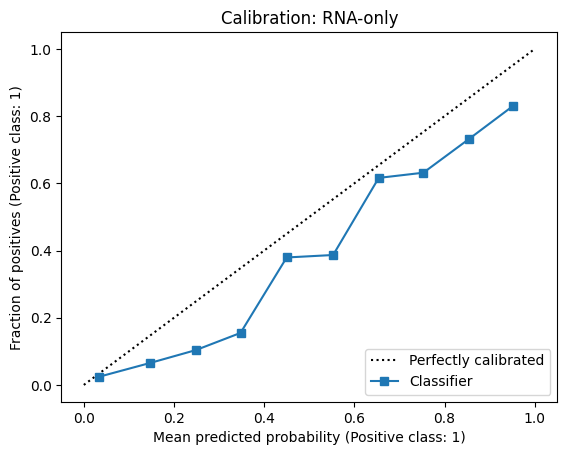

In [15]:
holdout_results = pd.DataFrame([dummy_metrics, meta_metrics, rna_metrics])
holdout_results = holdout_results.sort_values("auprc", ascending=False).reset_index(drop=True)
display(holdout_results)

ci_rows = []
for model_name, proba in [
    ("metadata_only_cancer_type", meta_test_proba),
    ("rna_only_elastic_net_logreg", rna_test_proba),
]:
    auroc_lo, auroc_med, auroc_hi = bootstrap_metric_ci(y_test, proba, roc_auc_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    auprc_lo, auprc_med, auprc_hi = bootstrap_metric_ci(y_test, proba, average_precision_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    ci_rows.append({
        "model": model_name,
        "auroc_ci_2.5": auroc_lo,
        "auroc_ci_50": auroc_med,
        "auroc_ci_97.5": auroc_hi,
        "auprc_ci_2.5": auprc_lo,
        "auprc_ci_50": auprc_med,
        "auprc_ci_97.5": auprc_hi,
    })

holdout_ci = pd.DataFrame(ci_rows)
display(holdout_ci)

CalibrationDisplay.from_predictions(y_test, meta_test_proba, n_bins=10)
plt.title("Calibration: cancer-type-only")
plt.show()

CalibrationDisplay.from_predictions(y_test, rna_test_proba, n_bins=10)
plt.title("Calibration: RNA-only")
plt.show()

## Cancer-type-grouped evaluation across all baselines

This is the main anti-confounding section.

By default, the grouped evaluation **reuses the best holdout hyperparameters** for the RNA and combined models so the notebook is more practical to run on Kaggle. If you want the strictest evaluation, change:

```python
GROUPED_TUNING_MODE = "nested"
```

That will tune the RNA and combined models inside each outer grouped fold, but it is much slower.

In [16]:
if RUN_GROUPED_CV:
    group_outer = StratifiedGroupKFold(
        n_splits=GROUP_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    group_inner = StratifiedGroupKFold(
        n_splits=max(3, GROUP_CV_SPLITS - 1),
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    group_rows = []

    for fold, (tr_idx, te_idx) in enumerate(group_outer.split(X_meta, y, groups), start=1):
        y_tr, y_te = y[tr_idx], y[te_idx]
        g_tr = groups[tr_idx]

        X_meta_tr = subset_X(X_meta, tr_idx)
        X_meta_te = subset_X(X_meta, te_idx)
        X_rna_tr = X_rna[tr_idx]
        X_rna_te = X_rna[te_idx]

        # Dummy
        dummy = DummyClassifier(strategy="prior")
        dummy.fit(np.zeros((len(tr_idx), 1)), y_tr)
        dummy_proba = dummy.predict_proba(np.zeros((len(te_idx), 1)))[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "dummy_prior",
            **evaluate_from_proba(y_te, dummy_proba),
        })

        # Metadata-only
        meta_search = GridSearchCV(
            estimator=meta_pipe,
            param_grid={"clf__C": META_C_GRID},
            scoring="average_precision",
            cv=group_inner,
            n_jobs=1,
            pre_dispatch=1,
            refit=True,
        )
        meta_search.fit(X_meta_tr, y_tr, groups=g_tr)
        meta_proba = meta_search.best_estimator_.predict_proba(X_meta_te)[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "metadata_only_cancer_type",
            **evaluate_from_proba(y_te, meta_proba),
        })

        # RNA-only
        if GROUPED_TUNING_MODE == "nested":
            rna_group_search = manual_cv_search_rna(
                X=X_rna_tr,
                y=y_tr,
                splitter=group_inner,
                param_grid=RNA_PARAM_GRID,
                search_backend=GPU_SEARCH_BACKEND,
                refit_backend=FINAL_REFIT_BACKEND,
                groups=g_tr,
                verbose=0,
                label=f"RNA_GROUP_FOLD_{fold}",
            )
            rna_group_artifact = rna_group_search["best_artifact"]
        else:
            rna_group_artifact = fit_rna_artifact(
                X_train=X_rna_tr,
                y_train=y_tr,
                params=rna_search["best_params"],
                backend=FINAL_REFIT_BACKEND,
            )
        rna_group_proba = predict_rna_artifact(rna_group_artifact, X_rna_te)
        group_rows.append({
            "fold": fold,
            "model": "rna_only_elastic_net_logreg",
            **evaluate_from_proba(y_te, rna_group_proba),
        })

        # Combined model
        if RUN_COMBINED_MODEL:
            if GROUPED_TUNING_MODE == "nested":
                combo_group_search = manual_cv_search_combo(
                    X_meta=X_meta_tr,
                    X_rna=X_rna_tr,
                    y=y_tr,
                    splitter=group_inner,
                    param_grid=COMBO_PARAM_GRID,
                    search_backend=GPU_SEARCH_BACKEND,
                    refit_backend=FINAL_REFIT_BACKEND,
                    groups=g_tr,
                    verbose=0,
                    label=f"COMBO_GROUP_FOLD_{fold}",
                )
                combo_group_artifact = combo_group_search["best_artifact"]
            else:
                combo_best_params = combo_search["best_params"] if combo_search is not None else rna_search["best_params"]
                combo_group_artifact = fit_combo_artifact(
                    X_meta_train=X_meta_tr,
                    X_rna_train=X_rna_tr,
                    y_train=y_tr,
                    params=combo_best_params,
                    backend=FINAL_REFIT_BACKEND,
                )
            combo_group_proba = predict_combo_artifact(combo_group_artifact, X_meta_te, X_rna_te)
            group_rows.append({
                "fold": fold,
                "model": "rna_plus_cancer_type",
                **evaluate_from_proba(y_te, combo_group_proba),
            })

        print(f"Completed grouped outer fold {fold}/{GROUP_CV_SPLITS}")

    group_results = pd.DataFrame(group_rows)
    display(group_results)

    group_summary = (
        group_results
        .groupby("model")[["auroc", "auprc", "balanced_accuracy", "f1", "brier"]]
        .agg(["mean", "std"])
    )
    display(group_summary)
else:
    print("RUN_GROUPED_CV is False; skipping grouped evaluation.")

[2026-04-29 15:53:14.192] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
Completed grouped outer fold 1/5
Completed grouped outer fold 2/5
Completed grouped outer fold 3/5
[2026-04-29 15:54:48.161] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
Completed grouped outer fold 4/5
[2026-04-29 15:55:04.865] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
Completed grouped outer fold 5/5


,fold,model,auroc,auprc,balanced_accuracy,f1,brier
0,1,dummy_prior,0.500000,0.588614,0.500000,0.000000,0.336051
1,1,metadata_only_cancer_type,0.500000,0.588614,0.500000,0.000000,0.256804
2,1,rna_only_elastic_net_logreg,0.794162,0.792338,0.749686,0.826087,0.173626
3,1,rna_plus_cancer_type,0.796030,0.793033,0.741193,0.824112,0.173713
4,2,dummy_prior,0.500000,0.451990,0.500000,0.000000,0.281679
5,2,metadata_only_cancer_type,0.500000,0.451990,0.500000,0.000000,0.247983
6,2,rna_only_elastic_net_logreg,0.633667,0.530727,0.613345,0.626418,0.286751
7,2,rna_plus_cancer_type,0.644294,0.548492,0.623121,0.643615,0.286176
8,3,dummy_prior,0.500000,0.284592,0.500000,0.000000,0.205097
9,3,metadata_only_cancer_type,0.500000,0.284592,0.500000,0.000000,0.232910


auroc               auprc            \
                                 mean       std      mean       std   
model                                                                 
dummy_prior                  0.500000  0.000000  0.332381  0.185075   
metadata_only_cancer_type    0.500000  0.000000  0.332381  0.185075   
rna_only_elastic_net_logreg  0.807176  0.103666  0.656199  0.093394   
rna_plus_cancer_type         0.808323  0.098460  0.661484  0.087831   

                            balanced_accuracy                  f1            \
                                         mean       std      mean       std   
model                                                                         
dummy_prior                          0.500000  0.000000  0.000000  0.000000   
metadata_only_cancer_type            0.500000  0.000000  0.000000  0.000000   
rna_only_elastic_net_logreg          0.735220  0.076995  0.662690  0.091822   
rna_plus_cancer_type                 0.737029  0.075284  0.669716  0.088222   

                                brier            
                                 mean       std  
model                                            
dummy_prior                  0.232892  0.073417  
metadata_only_cancer_type    0.242255  0.009920  
rna_only_elastic_net_logreg  0.162704  0.075027  
rna_plus_cancer_type         0.161992  0.075364

## Inspect RNA coefficients and optional biological sanity checks

This section strips Ensembl version suffixes, optionally maps to gene symbols, and checks overlap with the TP53 target list when possible.

In [17]:
best_rna_preproc = best_rna_artifact["preproc"]
final_features = extract_rna_feature_names(best_rna_preproc, gene_ids)
coef = np.asarray(best_rna_artifact["model"].coef_).ravel()

coef_df = pd.DataFrame({
    "ensembl_gene_id": final_features,
    "coefficient": coef,
})
coef_df["ensembl_gene_id_no_version"] = coef_df["ensembl_gene_id"].astype(str).str.replace(r"\..*$", "", regex=True)

def infer_ensembl_col(df):
    candidates = [
        "ensembl_gene_id",
        "ensembl_gene_id_no_version",
        "Ensembl",
        "ENSEMBL",
        "gene_id",
        "id",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def infer_symbol_col(df):
    candidates = [
        "gene_symbol",
        "symbol",
        "gene",
        "Gene",
        "HugoSymbol",
        "hgnc_symbol",
        "approved_symbol",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

annotation_loaded = False
if GENE_ANNOTATION_PATH is not None:
    gene_annot = pd.read_csv(GENE_ANNOTATION_PATH, sep=None, engine="python", low_memory=False)
    annot_ensembl_col = infer_ensembl_col(gene_annot)
    annot_symbol_col = infer_symbol_col(gene_annot)
    if annot_ensembl_col is not None and annot_symbol_col is not None:
        gene_map = gene_annot[[annot_ensembl_col, annot_symbol_col]].copy()
        gene_map.columns = ["ensembl_gene_id_raw", "gene_symbol"]
        gene_map["ensembl_gene_id_no_version"] = gene_map["ensembl_gene_id_raw"].astype(str).str.replace(r"\..*$", "", regex=True)
        gene_map = gene_map.drop_duplicates("ensembl_gene_id_no_version")
        coef_df = coef_df.merge(
            gene_map[["ensembl_gene_id_no_version", "gene_symbol"]],
            on="ensembl_gene_id_no_version",
            how="left",
        )
        annotation_loaded = True

coef_df["is_tp53_target"] = False
if TP53_TARGETS_PATH is not None and TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH, low_memory=False)
    target_ensembl_col = infer_ensembl_col(tp53_targets)
    target_symbol_col = infer_symbol_col(tp53_targets)

    if target_ensembl_col is not None:
        target_ids = (
            tp53_targets[target_ensembl_col]
            .astype(str)
            .str.replace(r"\..*$", "", regex=True)
            .dropna()
            .unique()
        )
        coef_df["is_tp53_target"] = coef_df["ensembl_gene_id_no_version"].isin(target_ids)
    elif target_symbol_col is not None and "gene_symbol" in coef_df.columns:
        target_symbols = tp53_targets[target_symbol_col].astype(str).dropna().unique()
        coef_df["is_tp53_target"] = coef_df["gene_symbol"].astype(str).isin(target_symbols)

coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

print("Top positive coefficients:")
display(coef_df.head(TOP_COEFS_TO_SHOW))

print("Top negative coefficients:")
display(coef_df.tail(TOP_COEFS_TO_SHOW).sort_values("coefficient"))

print("TP53-target overlap among selected RNA features:", int(coef_df["is_tp53_target"].sum()))
if "gene_symbol" in coef_df.columns:
    print("Gene symbol annotation loaded:", annotation_loaded)
else:
    print("No gene symbol annotation available; showing Ensembl IDs only.")

Top positive coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,is_tp53_target
0,ENSG00000203812.2,0.717308,ENSG00000203812,False
1,ENSG00000101349.16,0.502764,ENSG00000101349,False
2,ENSG00000187527.10,0.405975,ENSG00000187527,False
3,ENSG00000215221.2,0.400911,ENSG00000215221,False
4,ENSG00000249413.2,0.396278,ENSG00000249413,False
5,ENSG00000080166.15,0.356235,ENSG00000080166,False
6,ENSG00000232480.1,0.351478,ENSG00000232480,False
7,ENSG00000240990.9,0.341020,ENSG00000240990,False
8,ENSG00000266578.1,0.317876,ENSG00000266578,False
9,ENSG00000184486.8,0.317797,ENSG00000184486,False


Top negative coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,is_tp53_target
1999,ENSG00000228528.1,-1.460228,ENSG00000228528,False
1998,ENSG00000251095.6,-1.239117,ENSG00000251095,False
1997,ENSG00000250337.5,-1.032072,ENSG00000250337,False
1996,ENSG00000248583.1,-0.594514,ENSG00000248583,False
1995,ENSG00000143217.8,-0.567729,ENSG00000143217,False
1994,ENSG00000168070.11,-0.452049,ENSG00000168070,False
1993,ENSG00000197084.5,-0.434173,ENSG00000197084,False
1992,ENSG00000269941.1,-0.361819,ENSG00000269941,False
1991,ENSG00000105278.10,-0.321300,ENSG00000105278,False
1990,ENSG00000225742.5,-0.314967,ENSG00000225742,False


TP53-target overlap among selected RNA features: 0
No gene symbol annotation available; showing Ensembl IDs only.


## Combined model on the random holdout

This tests whether adding cancer type to RNA improves random-holdout performance.

COMBO search: 1/144 combos done | current best mean CV AUPRC = 0.6809
[2026-04-29 15:58:05.789] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 15:58:20.395] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 15:59:59.911] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 16:00:38.670] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 16:00:45.874] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 16:01:00.389] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 16:01:24.202] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-04-29 16:06:17.495] [CUML] [warning] QWL-QN stopp

,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.100,1000,1.0,maxabs,5000,0.816107,0.018814
1,0.100,1000,0.5,maxabs,5000,0.814788,0.019627
2,0.100,1000,1.0,standard,5000,0.811368,0.021094
3,0.010,1000,0.0,maxabs,5000,0.808822,0.017957
4,0.010,1000,0.0,standard,5000,0.804123,0.020566
5,0.001,1000,0.0,standard,5000,0.803378,0.015338
6,0.100,1000,0.5,standard,5000,0.801486,0.021908
7,0.100,1000,0.0,maxabs,5000,0.800897,0.020579
8,0.010,1000,0.5,standard,5000,0.798401,0.016460
9,1.000,500,1.0,maxabs,5000,0.794762,0.013575



rna_plus_cancer_type


,value
model,rna_plus_cancer_type
auroc,0.905283
auprc,0.78885
balanced_accuracy,0.852423
f1,0.779434
brier,0.118246


Confusion matrix:


,pred_0,pred_1
true_0,1120,215
true_1,81,523


Classification report:
              precision    recall  f1-score   support

           0      0.933     0.839     0.883      1335
           1      0.709     0.866     0.779       604

    accuracy                          0.847      1939
   macro avg      0.821     0.852     0.831      1939
weighted avg      0.863     0.847     0.851      1939



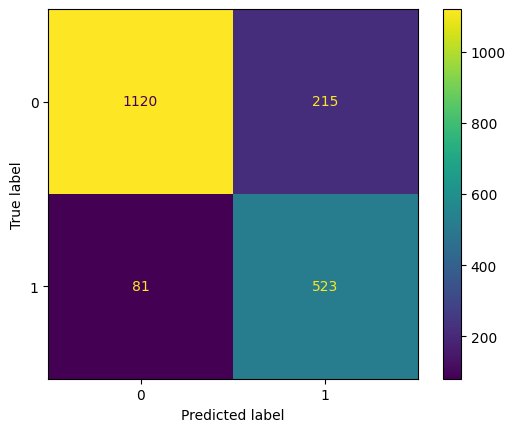

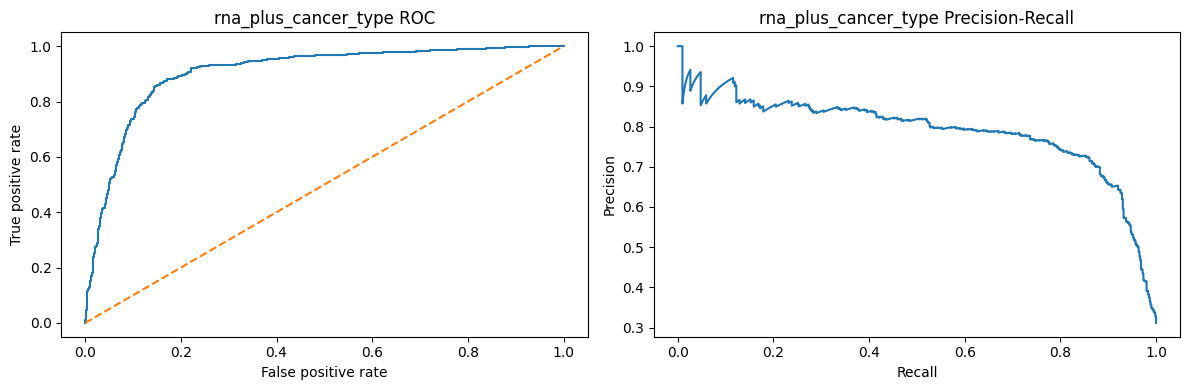

,model,auroc,auprc,balanced_accuracy,f1,brier
0,rna_plus_cancer_type,0.905283,0.788850,0.852423,0.779434,0.118246
1,rna_only_elastic_net_logreg,0.905968,0.780650,0.844066,0.770504,0.117723
2,metadata_only_cancer_type,0.824180,0.647466,0.749707,0.649492,0.179839
3,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


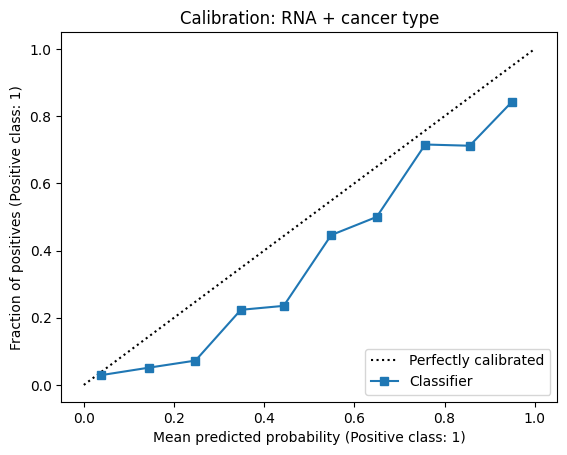

In [18]:
if RUN_COMBINED_MODEL:
    if combo_search is None:
        combo_search = manual_cv_search_combo(
            X_meta=X_meta_train,
            X_rna=X_rna_train,
            y=y_train,
            splitter=inner_cv,
            param_grid=COMBO_PARAM_GRID,
            search_backend=GPU_SEARCH_BACKEND,
            refit_backend=FINAL_REFIT_BACKEND,
            groups=None,
            verbose=1,
            label="COMBO",
        )
    else:
        print("Reusing previously computed combined-model search results.")

    print("Best combined params:", combo_search["best_params"])
    print("Best combined CV AUPRC:", combo_search["best_score"])
    display(combo_search["cv_results"].head(10))

    best_combo_artifact = combo_search["best_artifact"]
    combo_test_proba = predict_combo_artifact(best_combo_artifact, X_meta=X_meta_test, X_rna=X_rna_test)
    combo_metrics = pd.Series({"model": "rna_plus_cancer_type", **evaluate_from_proba(y_test, combo_test_proba)})

    print()
    print("rna_plus_cancer_type")
    display(combo_metrics.to_frame("value"))

    combo_test_pred = (combo_test_proba >= 0.5).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, combo_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report:")
    print(classification_report(y_test, combo_test_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y_test, combo_test_pred)
    plt.show()
    plot_roc_pr_curves(y_test, combo_test_proba, title_prefix="rna_plus_cancer_type")

    holdout_results_combo = pd.DataFrame([dummy_metrics, meta_metrics, rna_metrics, combo_metrics])
    holdout_results_combo = holdout_results_combo.sort_values("auprc", ascending=False).reset_index(drop=True)
    display(holdout_results_combo)

    CalibrationDisplay.from_predictions(y_test, combo_test_proba, n_bins=10)
    plt.title("Calibration: RNA + cancer type")
    plt.show()
else:
    combo_search = None
    best_combo_artifact = None
    combo_test_proba = None
    combo_metrics = None
    print("RUN_COMBINED_MODEL is False; skipping combined-model evaluation.")

## Within-cancer RNA evaluation

This asks whether the RNA model still carries TP53 signal **within individual tumour types**, not just across pan-cancer mixtures.

,cancer_type,n_samples,n_pos,n_neg,prevalence,cv_auroc_mean,cv_auroc_std,cv_auprc_mean,cv_auprc_std
8,LGG,510,241,269,0.472549,0.953792,0.021862,0.939196,0.033119
3,COAD,284,160,124,0.563380,0.855484,0.054102,0.875682,0.047399
6,HNSC,518,351,167,0.677606,0.775976,0.019743,0.846988,0.021052
4,ESCA,180,153,27,0.850000,0.490072,0.161297,0.844571,0.068518
17,UCEC,180,92,88,0.511111,0.816397,0.028789,0.818534,0.040194
11,LUSC,495,394,101,0.795960,0.540635,0.083295,0.812077,0.032894
10,LUAD,513,257,256,0.500975,0.823067,0.034720,0.801721,0.052856
12,PAAD,178,103,75,0.578652,0.732444,0.091929,0.801183,0.069065
0,BLCA,406,194,212,0.477833,0.814998,0.055607,0.796151,0.050123
9,LIHC,367,107,260,0.291553,0.854654,0.029279,0.714264,0.043154


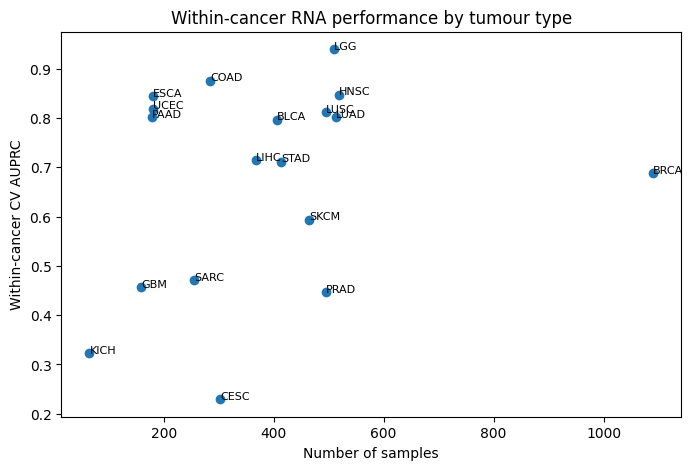

In [19]:
if RUN_WITHIN_CANCER_EVAL:
    within_cancer_rows = []
    for cancer_type, idx in model_meta.groupby(CANCER_TYPE_COL).groups.items():
        idx = np.array(list(idx))
        y_sub = y[idx]
        counts = pd.Series(y_sub).value_counts()
        n_neg = int(counts.get(0, 0))
        n_pos = int(counts.get(1, 0))
        if n_neg < MIN_SAMPLES_PER_CLASS or n_pos < MIN_SAMPLES_PER_CLASS:
            continue

        cv_splits = min(5, n_neg, n_pos)
        if cv_splits < 3:
            continue

        sub_cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        sub_scores = crossval_fixed_rna_params(
            X=X_rna[idx],
            y=y_sub,
            splitter=sub_cv,
            params=rna_search["best_params"],
            backend=WITHIN_CANCER_BACKEND,
        )

        within_cancer_rows.append({
            "cancer_type": cancer_type,
            "n_samples": len(idx),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "prevalence": n_pos / len(idx),
            "cv_auroc_mean": float(sub_scores["auroc"].mean()),
            "cv_auroc_std": float(sub_scores["auroc"].std(ddof=0)),
            "cv_auprc_mean": float(sub_scores["auprc"].mean()),
            "cv_auprc_std": float(sub_scores["auprc"].std(ddof=0)),
        })

    within_cancer_df = pd.DataFrame(within_cancer_rows).sort_values("cv_auprc_mean", ascending=False)
    display(within_cancer_df)

    if len(within_cancer_df) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(within_cancer_df["n_samples"], within_cancer_df["cv_auprc_mean"])
        for _, row in within_cancer_df.iterrows():
            plt.text(row["n_samples"], row["cv_auprc_mean"], row["cancer_type"], fontsize=8)
        plt.xlabel("Number of samples")
        plt.ylabel("Within-cancer CV AUPRC")
        plt.title("Within-cancer RNA performance by tumour type")
        plt.show()
else:
    print("RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.")

## Interpretation checklist

When you run this notebook, focus on these comparisons in order:

1. Does **RNA-only** beat **cancer-type-only** on the random holdout?
2. Under **cancer-type-grouped CV**, does RNA still beat the grouped metadata baseline?
3. Does **RNA + cancer type** improve on RNA-only?
4. Within individual tumour types, is there still useful TP53 signal?
5. Are the top coefficients biologically readable, and do any overlap the TP53 target list?

The grouped comparison should be treated as more trustworthy than the random holdout for judging pan-cancer generalization.

If runtime is too high, the safest first speed knob is to keep the same holdout search but leave:

```python
GROUPED_TUNING_MODE = "reuse_holdout_best"
```

instead of switching to nested grouped tuning.